# Logistic Regression with Aurora-GLM

This notebook demonstrates binomial logistic regression for binary classification using Aurora-GLM.

Logistic regression is used when the response variable is binary (0/1). It assumes:
- The response follows a Binomial distribution
- The logit (log-odds) of the probability is a linear combination of predictors

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.models.glm import fit_glm
from aurora.validation.metrics import accuracy_score, concordance_index, log_loss, brier_score_loss

# Set random seed for reproducibility
rng = np.random.default_rng(123)

## Generate Synthetic Binary Classification Data

We'll simulate binary outcomes that depend on two predictors.

In [2]:
# Generate predictors
n_samples = 300
X = rng.normal(size=(n_samples, 2))

# True coefficients
true_coef = np.array([1.2, -0.9])
true_intercept = 0.3

# Generate binary outcomes using logistic function
linear_predictor = true_intercept + X @ true_coef
probabilities = 1 / (1 + np.exp(-linear_predictor))
y = rng.binomial(1, probabilities)

print(f"Generated {n_samples} samples")
print(f"Class distribution:")
print(f"  Class 0: {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)")
print(f"  Class 1: {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)")

Generated 300 samples
Class distribution:
  Class 0: 114 (38.0%)
  Class 1: 186 (62.0%)


## Visualize the Data

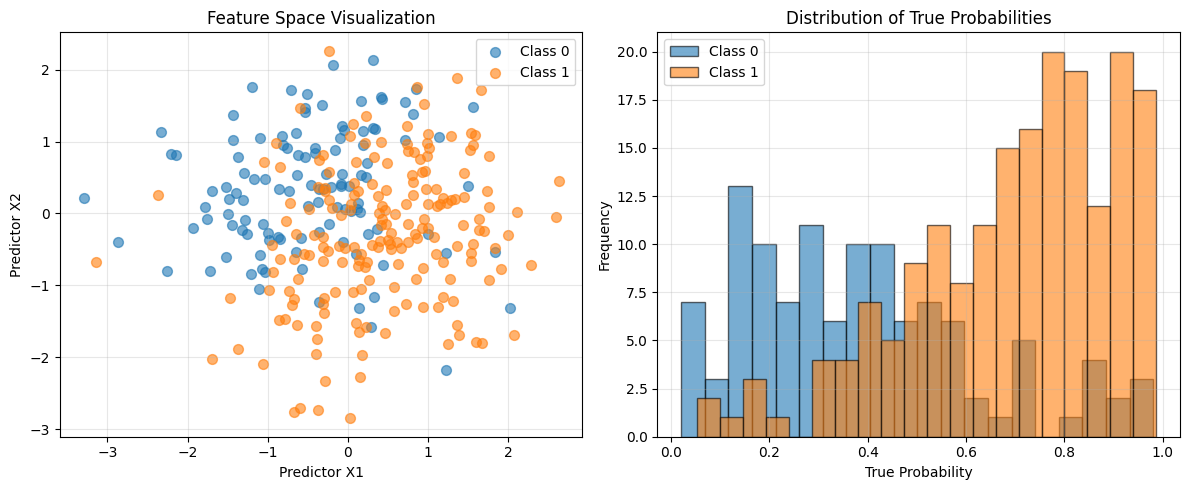

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2D scatter plot colored by class
axes[0].scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.6, label='Class 0', s=50)
axes[0].scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.6, label='Class 1', s=50)
axes[0].set_xlabel('Predictor X1')
axes[0].set_ylabel('Predictor X2')
axes[0].set_title('Feature Space Visualization')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histogram of true probabilities
axes[1].hist(probabilities[y == 0], bins=20, alpha=0.6, label='Class 0', edgecolor='black')
axes[1].hist(probabilities[y == 1], bins=20, alpha=0.6, label='Class 1', edgecolor='black')
axes[1].set_xlabel('True Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of True Probabilities')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Fit Logistic Regression Model

We'll fit a binomial GLM with logit link (logistic regression).

In [4]:
# Fit the model
result = fit_glm(X, y, family='binomial', link='logit')

print("Model converged:", result.converged_)
print(f"Number of iterations: {result.n_iter_}")
print(f"\nEstimated intercept: {result.intercept_:.4f} (true: {true_intercept:.4f})")
print(f"Estimated coefficients: {result.coef_}")
print(f"True coefficients: {true_coef}")

Model converged: True
Number of iterations: 5

Estimated intercept: 0.5432 (true: 0.3000)
Estimated coefficients: [ 1.23389408 -0.93948284]
True coefficients: [ 1.2 -0.9]


## Model Summary

View comprehensive summary with coefficient estimates, standard errors, and significance tests.

In [5]:
print(result.summary())

                       Generalized Linear Model Results                       
Family:                   Binomial                   Link function:  Logit
No. Observations:         300                        Df Residuals:   297
Df Model:                 2                         
Converged:                Yes                        No. Iterations: 5
                   coef    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
   intercept     0.5432     0.1442      3.767      0.000     0.2606     0.8258 ***
          X0     1.2339     0.1781      6.928      0.000     0.8848     1.5830 ***
          X1    -0.9395     0.1668     -5.633      0.000    -1.2663    -0.6126 ***
Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Deviance:                               298.48 Null Deviance:           398.44
AIC:                                    304.48 BIC:                     315.59
Pseudo R-squared:

## Model Diagnostics

Inspect model fit using diagnostic plots.

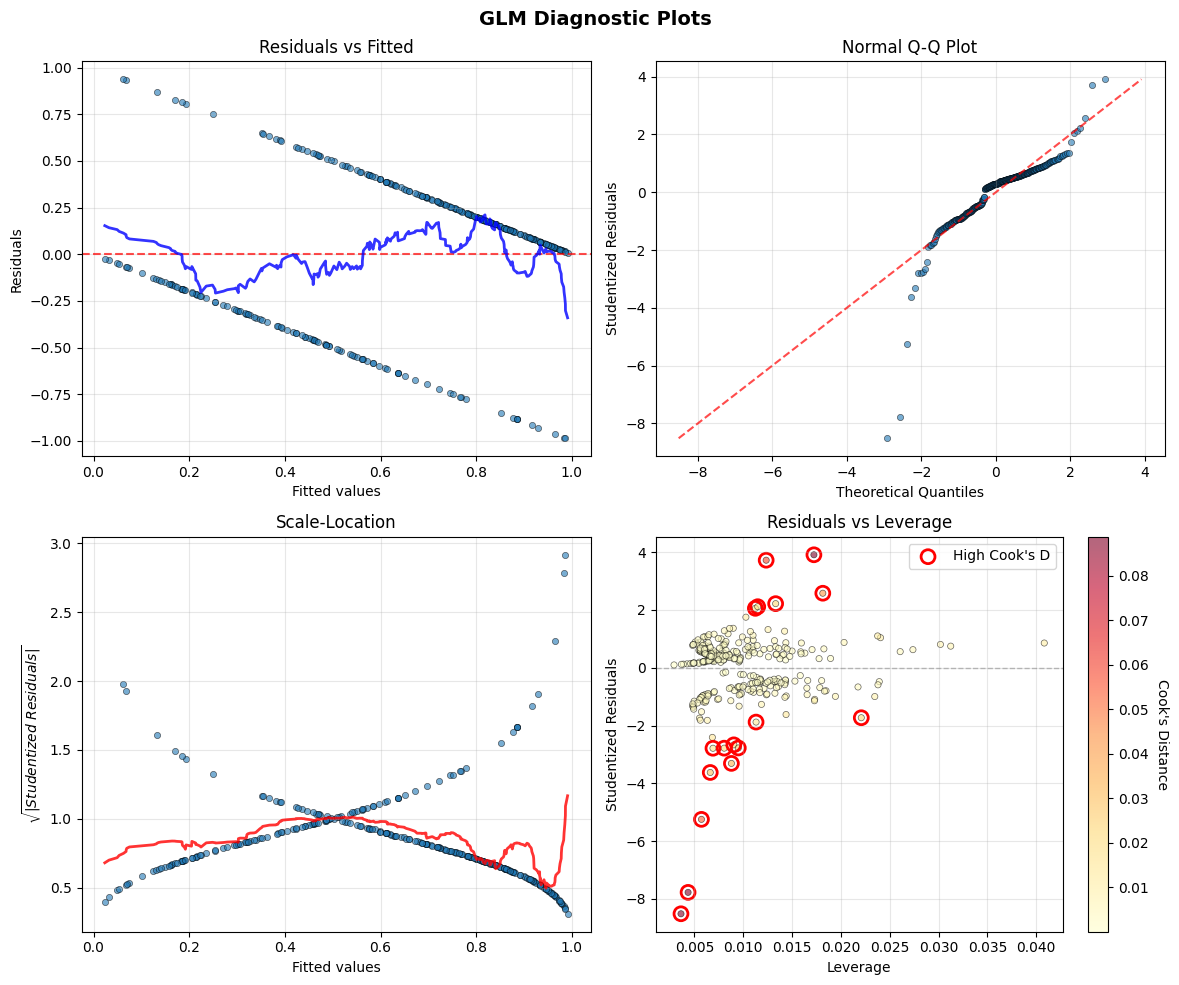

In [6]:
# Generate diagnostic plots
fig = result.plot_diagnostics(figsize=(12, 10))
plt.show()

## Predictions and Classification

Generate predicted probabilities and classify using a 0.5 threshold.

Classification Accuracy: 0.7933


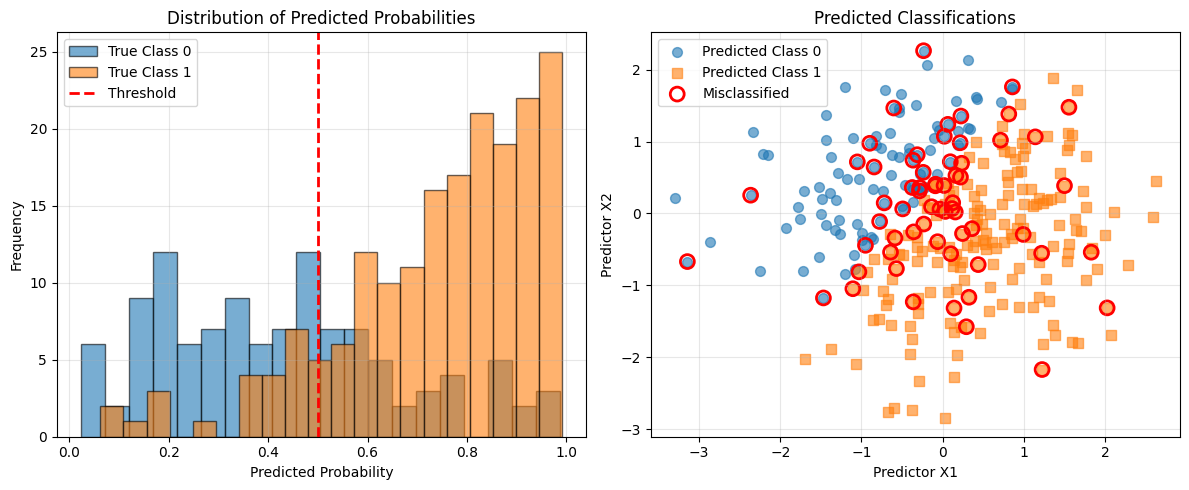

In [7]:
# Predict probabilities
y_prob = result.predict(X, type='response')

# Classify using 0.5 threshold
y_pred_class = (y_prob >= 0.5).astype(int)

# Calculate accuracy
acc = accuracy_score(y, y_pred_class)
print(f"Classification Accuracy: {acc:.4f}")

# Visualize predicted probabilities
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of predicted probabilities by true class
axes[0].hist(y_prob[y == 0], bins=20, alpha=0.6, label='True Class 0', edgecolor='black')
axes[0].hist(y_prob[y == 1], bins=20, alpha=0.6, label='True Class 1', edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', lw=2, label='Threshold')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Predicted Probabilities')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2D scatter colored by predicted class
axes[1].scatter(X[y_pred_class == 0, 0], X[y_pred_class == 0, 1], 
                alpha=0.6, label='Predicted Class 0', s=50, marker='o')
axes[1].scatter(X[y_pred_class == 1, 0], X[y_pred_class == 1, 1], 
                alpha=0.6, label='Predicted Class 1', s=50, marker='s')
# Mark misclassifications
misclassified = (y != y_pred_class)
axes[1].scatter(X[misclassified, 0], X[misclassified, 1], 
                edgecolors='red', facecolors='none', s=100, linewidths=2, label='Misclassified')
axes[1].set_xlabel('Predictor X1')
axes[1].set_ylabel('Predictor X2')
axes[1].set_title('Predicted Classifications')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Classification Metrics

Evaluate model performance using various classification metrics.

In [8]:
# Concordance index (C-statistic / AUROC)
c_index = concordance_index(y, y_prob)
print(f"Concordance Index (AUROC): {c_index:.4f}")

# Log loss (cross-entropy)
logloss = log_loss(y, y_prob)
print(f"Log Loss: {logloss:.4f}")

# Brier score
brier = brier_score_loss(y, y_prob)
print(f"Brier Score: {brier:.4f}")

# Confusion matrix
tp = np.sum((y == 1) & (y_pred_class == 1))
tn = np.sum((y == 0) & (y_pred_class == 0))
fp = np.sum((y == 0) & (y_pred_class == 1))
fn = np.sum((y == 1) & (y_pred_class == 0))

print(f"\nConfusion Matrix:")
print(f"               Predicted 0   Predicted 1")
print(f"Actual 0       {tn:>11}   {fp:>11}")
print(f"Actual 1       {fn:>11}   {tp:>11}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Concordance Index (AUROC): 0.8362
Log Loss: 0.4975
Brier Score: 0.1562

Confusion Matrix:
               Predicted 0   Predicted 1
Actual 0                76            38
Actual 1                24           162

Precision: 0.8100
Recall: 0.8710
F1 Score: 0.8394


## ROC Curve (Manual Calculation)

Visualize the trade-off between true positive rate and false positive rate.

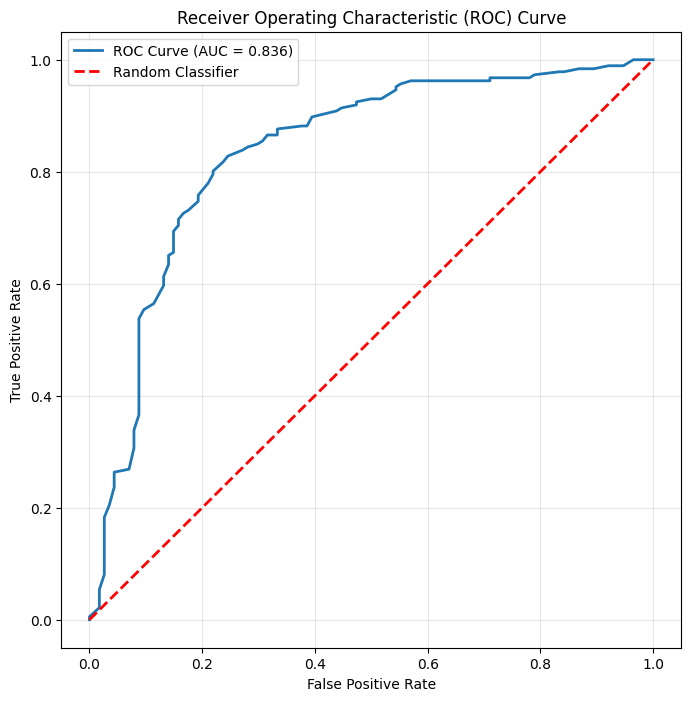

In [9]:
# Calculate ROC curve points
thresholds = np.linspace(0, 1, 100)
tpr_list = []
fpr_list = []

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)
    tp_t = np.sum((y == 1) & (y_pred_t == 1))
    fn_t = np.sum((y == 1) & (y_pred_t == 0))
    tn_t = np.sum((y == 0) & (y_pred_t == 0))
    fp_t = np.sum((y == 0) & (y_pred_t == 1))
    
    tpr = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    fpr = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr_list, tpr_list, lw=2, label=f'ROC Curve (AUC = {c_index:.3f})')
plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Decision Boundary Visualization

Visualize the decision boundary learned by the model.

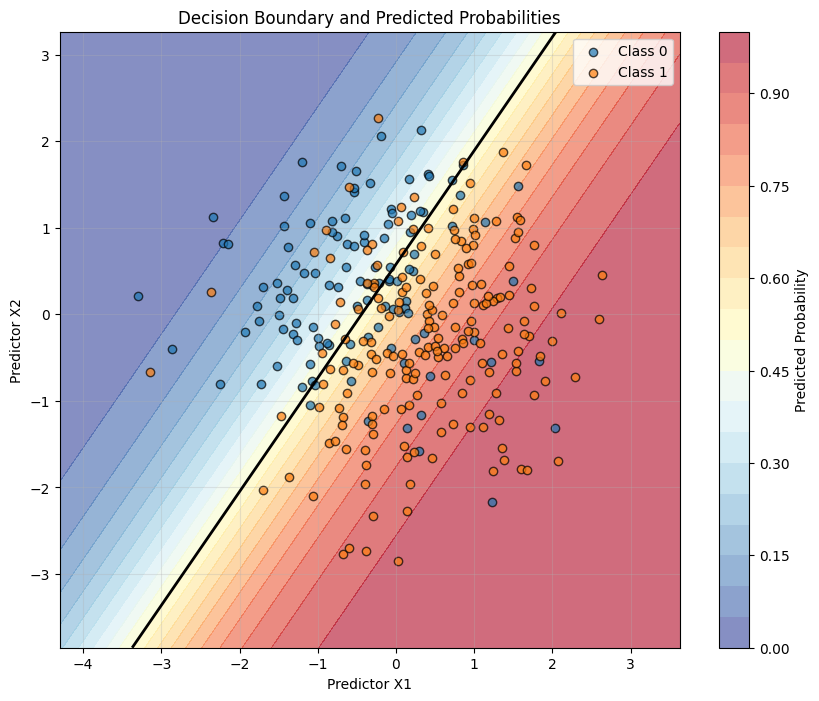

In [10]:
# Create a grid for decision boundary
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))

# Predict probabilities for grid
X_grid = np.c_[xx1.ravel(), xx2.ravel()]
Z = result.predict(X_grid, type='response').reshape(xx1.shape)

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx1, xx2, Z, levels=20, cmap='RdYlBu_r', alpha=0.6)
plt.colorbar(label='Predicted Probability')
plt.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.7, label='Class 0', edgecolors='black')
plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.7, label='Class 1', edgecolors='black')
plt.xlabel('Predictor X1')
plt.ylabel('Predictor X2')
plt.title('Decision Boundary and Predicted Probabilities')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Conclusion

This notebook demonstrated:
1. Generating synthetic binary classification data
2. Fitting a logistic regression model with Aurora-GLM
3. Viewing model summaries and diagnostics
4. Making probabilistic predictions
5. Evaluating classification performance with multiple metrics
6. Visualizing the ROC curve and decision boundary

Logistic regression is a powerful and interpretable method for binary classification tasks, and the concordance index (AUROC) provides a threshold-independent measure of model performance.